# 01 — Exploratory Data Analysis

Explore `rating.csv` (7.8M user–anime interactions) and `anime.csv` (12,294 titles).

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from src.data import load_raw

ratings, anime = load_raw()
print(f'ratings: {ratings.shape} | anime: {anime.shape}')

ratings: (7813737, 3) | anime: (12294, 7)


## 1. Dataset Overview

In [2]:
print('=== ratings ===')
print(ratings.dtypes)
print()
ratings.head()

=== ratings ===
user_id     int64
anime_id    int64
rating      int64
dtype: object



,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1


In [3]:
print('=== anime ===')
print(anime.dtypes)
print()
anime.head()

=== anime ===
anime_id      int64
name         object
genre        object
type         object
episodes     object
rating      float64
members       int64
dtype: object



,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [4]:
print('Missing values in anime:')
print(anime.isnull().sum())

Missing values in anime:
anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64


## 2. Ratings Distribution

Rating `-1` means the user watched but did not rate the anime.

In [5]:
n_unrated = (ratings['rating'] == -1).sum()
n_rated = (ratings['rating'] != -1).sum()
print(f'Rated interactions:   {n_rated:,} ({n_rated/len(ratings)*100:.1f}%)')
print(f'Unrated (watched):    {n_unrated:,} ({n_unrated/len(ratings)*100:.1f}%)')

Rated interactions:   6,337,241 (81.1%)
Unrated (watched):    1,476,496 (18.9%)


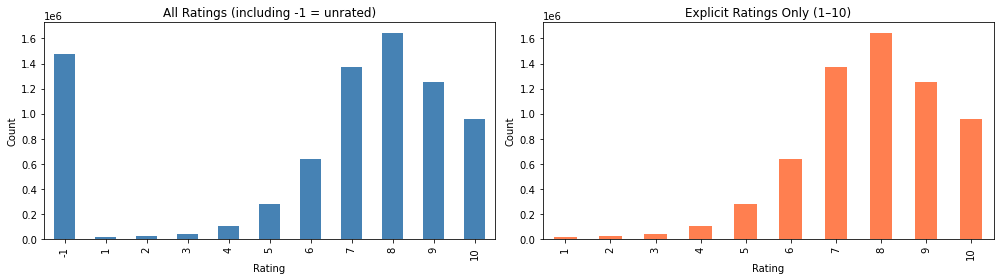

Mean explicit rating: 7.81


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# All ratings including -1
ratings['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('All Ratings (including -1 = unrated)')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Explicit ratings only
explicit = ratings[ratings['rating'] != -1]
explicit['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Explicit Ratings Only (1–10)')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../data/processed/rating_distribution.png', dpi=150)
plt.show()
print(f'Mean explicit rating: {explicit["rating"].mean():.2f}')

## 3. User Activity

In [7]:
ratings_per_user = explicit.groupby('user_id')['rating'].count()
print(f'Total unique users:        {ratings["user_id"].nunique():,}')
print(f'Users with explicit ratings: {ratings_per_user.shape[0]:,}')
print(f'\nRatings per user:')
print(ratings_per_user.describe())

Total unique users:        73,515
Users with explicit ratings: 69,600

Ratings per user:
count    69600.000000
mean        91.052313
std        135.764253
min          1.000000
25%         13.000000
50%         45.000000
75%        114.000000
max       3747.000000
Name: rating, dtype: float64


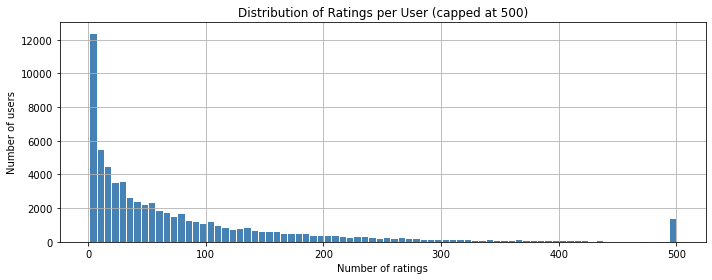

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ratings_per_user.clip(upper=500).hist(bins=80, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribution of Ratings per User (capped at 500)')
ax.set_xlabel('Number of ratings')
ax.set_ylabel('Number of users')
plt.tight_layout()
plt.savefig('../data/processed/ratings_per_user.png', dpi=150)
plt.show()

## 4. Anime Popularity

In [9]:
ratings_per_anime = explicit.groupby('anime_id')['rating'].count().sort_values(ascending=False)
print(f'Total unique anime in ratings: {ratings_per_anime.shape[0]:,}')
print(f'\nRatings per anime:')
print(ratings_per_anime.describe())

Total unique anime in ratings: 9,927

Ratings per anime:
count     9927.000000
mean       638.384305
std       1795.865541
min          1.000000
25%          9.000000
50%         57.000000
75%        395.000000
max      34226.000000
Name: rating, dtype: float64


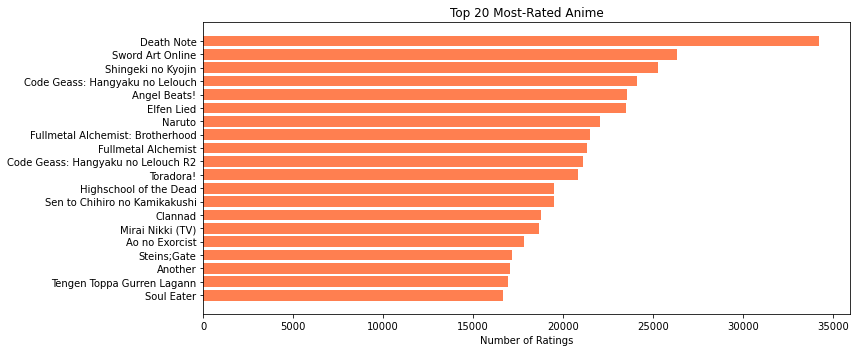

In [10]:
# Top 20 most-rated anime
top20 = ratings_per_anime.head(20).reset_index()
top20 = top20.merge(anime[['anime_id', 'name']], on='anime_id')

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top20['name'][::-1], top20['rating'][::-1], color='coral')
ax.set_title('Top 20 Most-Rated Anime')
ax.set_xlabel('Number of Ratings')
plt.tight_layout()
plt.savefig('../data/processed/top20_anime.png', dpi=150)
plt.show()

## 5. Anime Catalogue Analysis

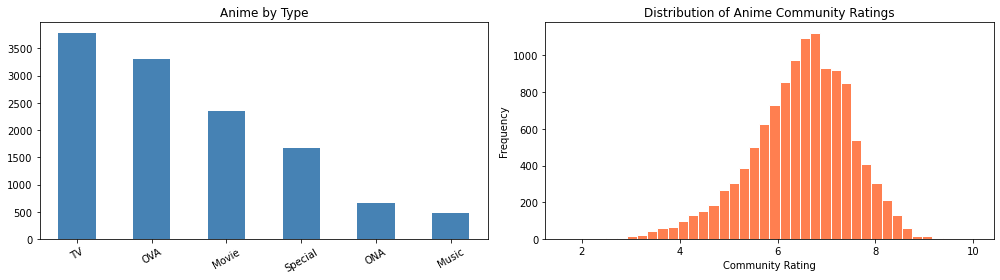

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Type distribution
anime['type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Anime by Type')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# Community rating distribution
anime['rating'].dropna().plot(kind='hist', bins=40, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Distribution of Anime Community Ratings')
axes[1].set_xlabel('Community Rating')

plt.tight_layout()
plt.savefig('../data/processed/anime_catalogue.png', dpi=150)
plt.show()

## 6. Genre Analysis

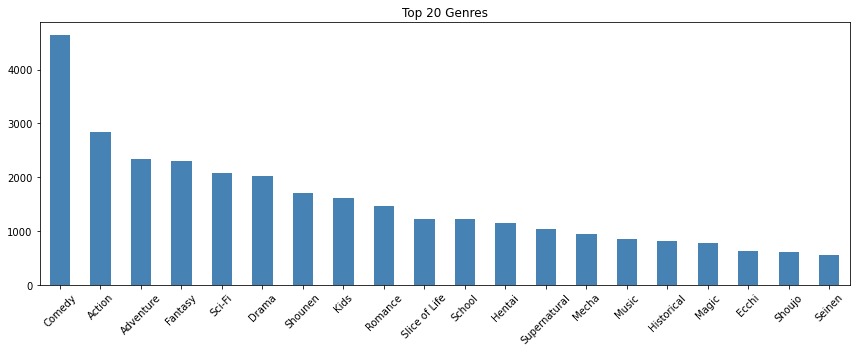

Total unique genres: 43


In [12]:
# Genres are comma-separated — explode into individual counts
genre_counts = (
    anime['genre']
    .dropna()
    .str.split(', ')
    .explode()
    .str.strip()
    .value_counts()
)

fig, ax = plt.subplots(figsize=(12, 5))
genre_counts.head(20).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 20 Genres')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../data/processed/top20_genres.png', dpi=150)
plt.show()

print(f'Total unique genres: {genre_counts.shape[0]}')

## 7. Sparsity of the Interaction Matrix

In [13]:
n_users = ratings['user_id'].nunique()
n_items = ratings['anime_id'].nunique()
n_interactions = len(explicit)

sparsity = 1 - (n_interactions / (n_users * n_items))

print(f'Unique users:          {n_users:,}')
print(f'Unique anime:          {n_items:,}')
print(f'Explicit interactions: {n_interactions:,}')
print(f'Matrix sparsity:       {sparsity*100:.2f}%')

Unique users:          73,515
Unique anime:          11,200
Explicit interactions: 6,337,241
Matrix sparsity:       99.23%


## 8. Key Takeaways

- **1.48M unrated interactions** (watched but not rated) — filter these before modelling
- **Ratings skew high** — most explicit ratings cluster between 7–9
- **Heavy long tail** — a few anime have thousands of ratings; most have very few
- **Matrix is ~99.9% sparse** — collaborative filtering is the right approach
- **Genre and type metadata available** — can be used as item side features
- **230 anime missing community rating, 62 missing genre** — handle in preprocessing